# 09 — Flag the flaggable, then test what remains

Notebook 08 showed the failures separate from clear images only on the colour
descriptors, and only because of a visually distinctive minority. This notebook
first classifies that minority by APPEARANCE-ONLY rules — no recall enters any
rule, so the flags are the kind a deployed system could apply a priori:
darkness (median grey luminance < 80; median resists point lights, so
night-in-disguise is caught by the same rule; Bronte et al. 2009; Radescu &
Gellert 2023), coloured dust (orange index > 25; Wei et al. 2025), and bright
uniform haze (RMS contrast ≤ 0.10, median brightness ≥ 120, not orange; the
scene-radiance-near-airlight limit of He et al. 2009). Rules apply in that
priority order and are validated visually before adoption.

What remains unflagged — the residual — is the candidate invisible set. The
formal question, and the deliverable of this notebook: can ANY descriptor, or
their combination, separate the residual failures from genuinely clear images?
(KS, Mann-Whitney, AUC; the claim standard is not "all p non-significant" but
"no deployable separator".)

Notebook 08 left us with 536 images the estimator scored as nearly clear, five
validated rulers to measure their appearance, and a question: the failures hiding
in this set — do they look different from the genuinely clear images? We load the
descriptor table and find out.

In [2]:
# Setup: load the descriptor table (536 labelled low-severity images).
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')
RAW_RTTS_DIR = "/content/drive/MyDrive/adaptive_perception_data/raw/RTTS"
OUTPUT_ROOT = "/content/drive/MyDrive/perception-difficulty-dve/results"
TABLES_DIR = os.path.join(OUTPUT_ROOT, "tables")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")
IMAGES_DIR = RAW_RTTS_DIR

data = pd.read_csv(os.path.join(TABLES_DIR, "lowsev_descriptors_RTTS.csv"))
print(f"{len(data)} images; groups:\n{data['group'].value_counts().to_string()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
536 images; groups:
group
intermediate    219
failure         214
clear           103


In [3]:
data

,stem,filename,relpath,severity,bin,rtdetr_l,yolo_nano,yolov8s,recall_mean,group,median_brightness_score,orange_index_score,channel_spread_score,rms_contrast_score,upper_contrast_score
0,AM_Bing_211,AM_Bing_211.png,JPEGImages/AM_Bing_211.png,0.279724,light,0.333333,0.666667,0.666667,0.555556,intermediate,102.0,-0.751922,6.713808,0.245551,0.247337
1,AM_Bing_232,AM_Bing_232.png,JPEGImages/AM_Bing_232.png,0.132810,clear,0.600000,0.533333,0.866667,0.666667,intermediate,111.0,-7.975333,7.975333,0.262716,0.258571
2,AM_Bing_422,AM_Bing_422.png,JPEGImages/AM_Bing_422.png,0.339370,light,0.300000,0.500000,0.200000,0.333333,intermediate,126.0,10.572869,13.701600,0.257811,0.251244
3,AM_Bing_464,AM_Bing_464.png,JPEGImages/AM_Bing_464.png,0.209904,clear,0.000000,0.000000,0.000000,0.000000,failure,51.0,4.977793,5.438498,0.106079,0.092733
4,AM_Bing_640,AM_Bing_640.png,JPEGImages/AM_Bing_640.png,0.186327,clear,0.769231,0.615385,0.615385,0.666667,intermediate,83.0,-1.570328,2.673805,0.192539,0.147424
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
531,hv6_166,hv6_166.png,JPEGImages/hv6_166.png,0.212088,clear,0.785714,0.571429,0.500000,0.619048,intermediate,104.0,29.039229,29.039229,0.227143,0.234732
532,hv6_204,hv6_204.png,JPEGImages/hv6_204.png,0.317653,light,0.153846,0.769231,0.846154,0.589744,intermediate,111.0,15.772616,15.772616,0.180838,0.195585
533,hv6_208,hv6_208.png,JPEGImages/hv6_208.png,0.342346,light,0.000000,0.555556,0.222222,0.259259,failure,121.0,26.862488,26.862488,0.168159,0.168635
534,hv6_96,hv6_96.png,JPEGImages/hv6_96.png,0.175420,clear,0.600000,0.300000,0.700000,0.533333,intermediate,75.0,22.342975,22.342975,0.268707,0.281813


First, flag what announces itself. Three rules, built from appearance alone — no
detection result enters any of them, so these are flags a deployed system could
raise before running a detector. A scene is flagged dark if its median luminance
falls below 70 (He et al., 2009: a dark scene keeps the dark channel low regardless
of fog); flagged as chromatic cast if its channel spread exceeds 35 (a strongly
coloured airlight, warm or cold, violates the achromatic assumption; Wei et al.,
2025); and flagged as bright uniform haze if it is bright yet nearly contrast-free
(the scene-radiance-near-airlight limit). Whatever no rule catches is the residual
— the candidate invisible set.

In [4]:
# Appearance-only mode classification, priority order: dark -> dust -> haze.
# No recall is used in any rule.
def classify_mode(row):
    """Flaggable appearance mode, or 'unflagged' (invisible candidate)."""
    if row["median_brightness_score"] < 70:
        return "dark"
    if row["channel_spread_score"] > 35:
        return "cast_warm" if row["orange_index_score"] > 0 else "cast_cold"
    if (row["rms_contrast_score"] <= 0.13
            and row["median_brightness_score"] >= 110
            and row["orange_index_score"] <= 35):
        return "bright_haze"
    return "unflagged"
data["mode"] = data.apply(classify_mode, axis=1)
print(pd.crosstab(data["mode"], data["group"]).to_string())

group        clear  failure  intermediate
mode                                     
bright_haze      1        0             1
cast_cold        7        3             6
cast_warm        5       34            14
dark            10       32            32
unflagged       80      145           166


A rule is only adopted after looking it in the eye. One sample grid per mode: the
dark grid should hold genuinely dark scenes, the cast grids coloured atmospheres,
and — the important one — the unflagged grid should look unremarkable. These
thresholds went through one visual calibration round (an earlier dark-region cue
was tested and rejected: dark pixels are scene content, not scene darkness) and
were then locked.

In [5]:
# Visual verification of each flag: sample grid per mode. A rule is adopted
# only if its grid looks like what the rule claims to catch.
def show_mode_grid(dataframe, mode_name, figure_filename, n_show=8):
    subset = dataframe[dataframe["mode"] == mode_name]
    sample = subset.sample(n=min(n_show, len(subset)), random_state=5)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7.5))
    for ax, (_, row) in zip(axes.ravel(), sample.iterrows()):
        image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
        ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"{row['group']} | bright {row['median_brightness_score']:.0f} | "
                     f"orange {row['orange_index_score']:.0f}", fontsize=8)
        ax.axis("off")
    for ax in axes.ravel()[len(sample):]:
        ax.axis("off")
    fig.suptitle(f"mode = {mode_name} (n = {len(subset)})", fontsize=12, y=1.0)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    figure_path = os.path.join(FIGURES_DIR, figure_filename)
    plt.savefig(figure_path, dpi=95, format="jpg", bbox_inches="tight")
    print("Saved:", figure_path)
    plt.show()

for mode_name in ["dark", "cast_warm", "cast_cold", "bright_haze", "unflagged"]:
    show_mode_grid(data, mode_name, f"fig_26_mode_{mode_name}.jpg")

Output hidden; open in https://colab.research.google.com to view.

The classification splits the 214 failures into 69 that carry a visible signature
— dark scenes, coloured casts — and 145 that carry none. Bright uniform haze is
essentially absent (n = 2), for a good physical reason: a bright whiteout drives
the dark channel high, so such scenes score heavy and never reach this low-severity
set at all. The stage is set: 145 unflagged failures against 80 genuinely clear
images, and the question of whether anything measurable tells them apart.

In [6]:
# The comparison sets for the overlap test: residual (unflagged) FAILURES vs
# genuinely CLEAR images. Save the full mode-labelled table.
invisible = data[(data["mode"] == "unflagged") & (data["group"] == "failure")]
clear = data[(data["mode"] == "unflagged") & (data["group"] == "clear")]
print(f"invisible candidates (unflagged failures): {len(invisible)}")
print(f"genuinely clear (unflagged clear):         {len(clear)}")
print(f"flagged failures: {int(((data['mode'] != 'unflagged') & (data['group'] == 'failure')).sum())} of 214")

data.to_csv(os.path.join(TABLES_DIR, "mode_labels_RTTS.csv"), index=False)
print("Saved:", os.path.join(TABLES_DIR, "mode_labels_RTTS.csv"))

invisible candidates (unflagged failures): 145
genuinely clear (unflagged clear):         80
flagged failures: 69 of 214
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/tables/mode_labels_RTTS.csv


The formal test. For each descriptor: do the two groups draw from different
distributions (Kolmogorov–Smirnov, Mann–Whitney), and — the question that actually
matters for deployment — can any threshold on the descriptor separate them (AUC)?
The claim standard is set in advance: with 145 versus 80 images, small shifts will
reach statistical significance; significance is not separability. The claim under
test is that no descriptor offers a usable operating point.

invisible n = 145   clear n = 80

       descriptor  KS_D     KS_p    MWU_p   AUC
median_brightness 0.263   0.0012 0.000606 0.638
     orange_index 0.173   0.0797    0.328 0.539
   channel_spread 0.283 0.000386 0.000198 0.650
     rms_contrast 0.255  0.00189 0.000583 0.639
   upper_contrast 0.324  2.6e-05 3.03e-05 0.668

Saved: /content/drive/MyDrive/perception-difficulty-dve/results/tables/descriptor_overlap_stats.csv
Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_27_descriptor_overlap.jpg


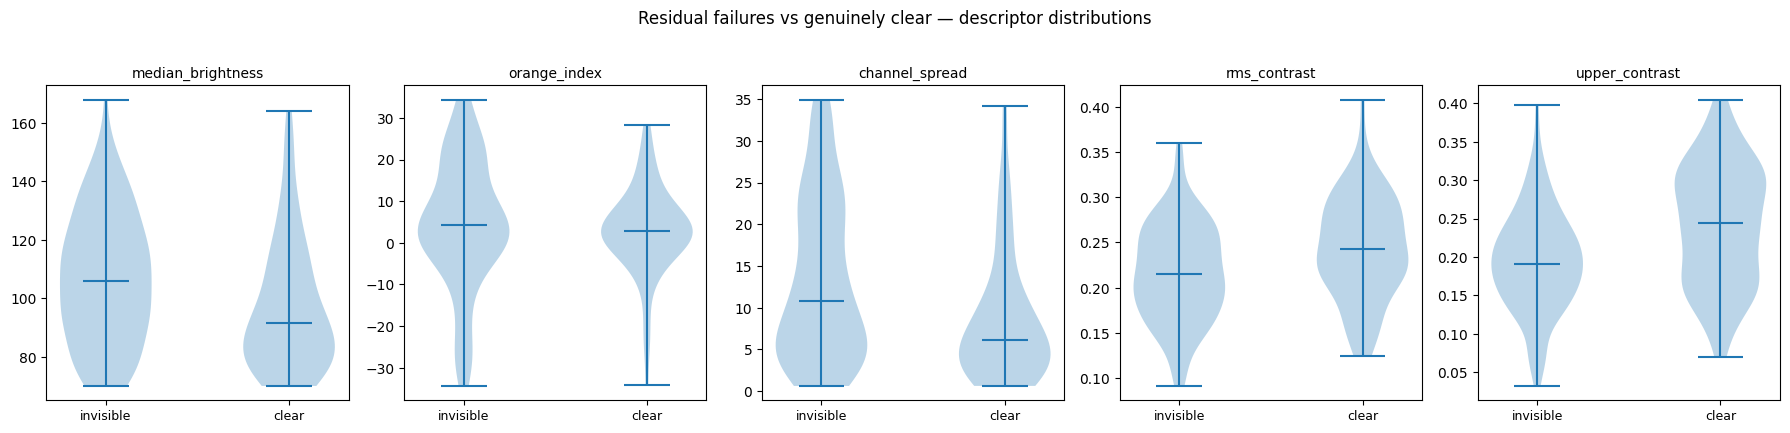

In [7]:
# THE OVERLAP TEST — residual (unflagged) failures vs genuinely clear, per
# descriptor: two-sample KS, Mann-Whitney U, and AUC. Claim standard: not
# "every p non-significant" but "no deployable separator" (AUC near chance).
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.metrics import roc_auc_score

DESCRIPTORS = ["median_brightness_score", "orange_index_score",
               "channel_spread_score", "rms_contrast_score", "upper_contrast_score"]

invisible = data[(data["mode"] == "unflagged") & (data["group"] == "failure")]
clear = data[(data["mode"] == "unflagged") & (data["group"] == "clear")]
print(f"invisible n = {len(invisible)}   clear n = {len(clear)}\n")

rows = []
for name in DESCRIPTORS:
    a, b = invisible[name].values, clear[name].values
    ks_stat, ks_p = ks_2samp(a, b)
    _, u_p = mannwhitneyu(a, b)
    auc = roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b])
    auc = max(auc, 1.0 - auc)   # separability regardless of direction
    rows.append({"descriptor": name.replace("_score", ""), "KS_D": round(ks_stat, 3),
                 "KS_p": f"{ks_p:.3g}", "MWU_p": f"{u_p:.3g}", "AUC": round(auc, 3)})

stats = pd.DataFrame(rows)
print(stats.to_string(index=False))
stats.to_csv(os.path.join(TABLES_DIR, "descriptor_overlap_stats.csv"), index=False)
print("\nSaved:", os.path.join(TABLES_DIR, "descriptor_overlap_stats.csv"))

fig, axes = plt.subplots(1, len(DESCRIPTORS), figsize=(3.6 * len(DESCRIPTORS), 4.2))
for ax, name in zip(axes, DESCRIPTORS):
    ax.violinplot([invisible[name], clear[name]], showmedians=True)
    ax.set_xticks([1, 2]); ax.set_xticklabels(["invisible", "clear"], fontsize=9)
    ax.set_title(name.replace("_score", ""), fontsize=10)
fig.suptitle("Residual failures vs genuinely clear — descriptor distributions", fontsize=12, y=1.02)
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_27_descriptor_overlap.jpg")
plt.savefig(figure_path, dpi=110, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

Two follow-ups make the numbers concrete. The medians show the direction of each
shift: the residual failures have LOWER far-field contrast than clear scenes
(0.191 vs 0.245) — an independent fog witness (Bronte et al., 2009) confirming the
fog is real — and they are BRIGHTER than clear scenes (106 vs 91.5), so this is
ordinary daylight, not hidden night. And the best available threshold on the
strongest descriptor tells the deployment story in one line: catching 92% of the
failures means falsely flagging 60% of the clear images. Detectable in aggregate;
unusable as a filter.

In [8]:
for name in ["upper_contrast_score", "rms_contrast_score", "median_brightness_score"]:
    print(f"{name:<26} invisible median {invisible[name].median():.3f}   "
          f"clear median {clear[name].median():.3f}")

# Concrete deployability check on the strongest descriptor: best threshold
# (Youden's J) and its operating trade-off.
from sklearn.metrics import roc_curve
labels_bin = np.r_[np.ones(len(invisible)), np.zeros(len(clear))]
scores = np.r_[invisible["upper_contrast_score"], clear["upper_contrast_score"]]
fpr, tpr, thresholds = roc_curve(labels_bin, -scores)   # low contrast = predict failure
j_best = np.argmax(tpr - fpr)
print(f"\nupper_contrast best threshold: catches {tpr[j_best]:.0%} of failures "
      f"while falsely flagging {fpr[j_best]:.0%} of clear images")

upper_contrast_score       invisible median 0.191   clear median 0.245
rms_contrast_score         invisible median 0.215   clear median 0.242
median_brightness_score    invisible median 106.000   clear median 91.500

upper_contrast best threshold: catches 92% of failures while falsely flagging 60% of clear images


Statistics say the residual cannot be flagged; they do not say what it is. Here is
all of it — every one of the 145 unflagged failures, hardest first, each with its
severity, recall, brightness, and orange index. What the eye finds comprises
ordinary grey daylight streets — masked pedestrians, cyclists, traffic — with genuine haze and abundant dark content (dark clothing, dark vehicles, tree lines); a small minority look genuinely clear, where near-zero recall likely reflects object difficulty rather than fog

In [9]:
# Inspect the ENTIRE residual failure set: every unflagged failure as a
# contact sheet, ordered by recall (hardest first), each with severity,
# recall, and the descriptor values. This is the mechanism hunt: what do
# these images have in common that no single descriptor captures?
residual = (data[(data["mode"] == "unflagged") & (data["group"] == "failure")]
            .sort_values("recall_mean").reset_index(drop=True))
print(f"residual failures: {len(residual)}")

n_cols = 8
n_rows = int(np.ceil(len(residual) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.6 * n_rows))
for ax, (_, row) in zip(axes.ravel(), residual.iterrows()):
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    ax.imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(f"s{row['severity']:.2f} r{row['recall_mean']:.2f} "
                 f"b{row['median_brightness_score']:.0f} o{row['orange_index_score']:.0f}",
                 fontsize=6)
    ax.axis("off")
for ax in axes.ravel()[len(residual):]:
    ax.axis("off")
fig.suptitle(f"ALL residual (unflagged) failures, hardest first (n = {len(residual)})",
             fontsize=13, y=1.002)
plt.tight_layout(rect=[0, 0, 1, 0.995])
figure_path = os.path.join(FIGURES_DIR, "fig_28_residual_contact_sheet.jpg")
plt.savefig(figure_path, dpi=80, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

And why the estimator misses them. For the twelve hardest, the image beside its
transmission map. The dark channel finds its near-zero pixels in dark scene content
— clothing, vehicles, shadow — that remains visible through the fog, reads high
transmission there, and concludes the air is clear (the scene-content transmission
offset: the term the standard derivation discards; Lee et al., 2016, Eq. 16).
The maps print bright exactly over dark clothing and vehicle bodies in visibly hazy frames — dark content read as clear air — with the mirror failure, dark spots, at headlights.

Saved: /content/drive/MyDrive/perception-difficulty-dve/results/figures/fig_29_residual_mechanism.jpg


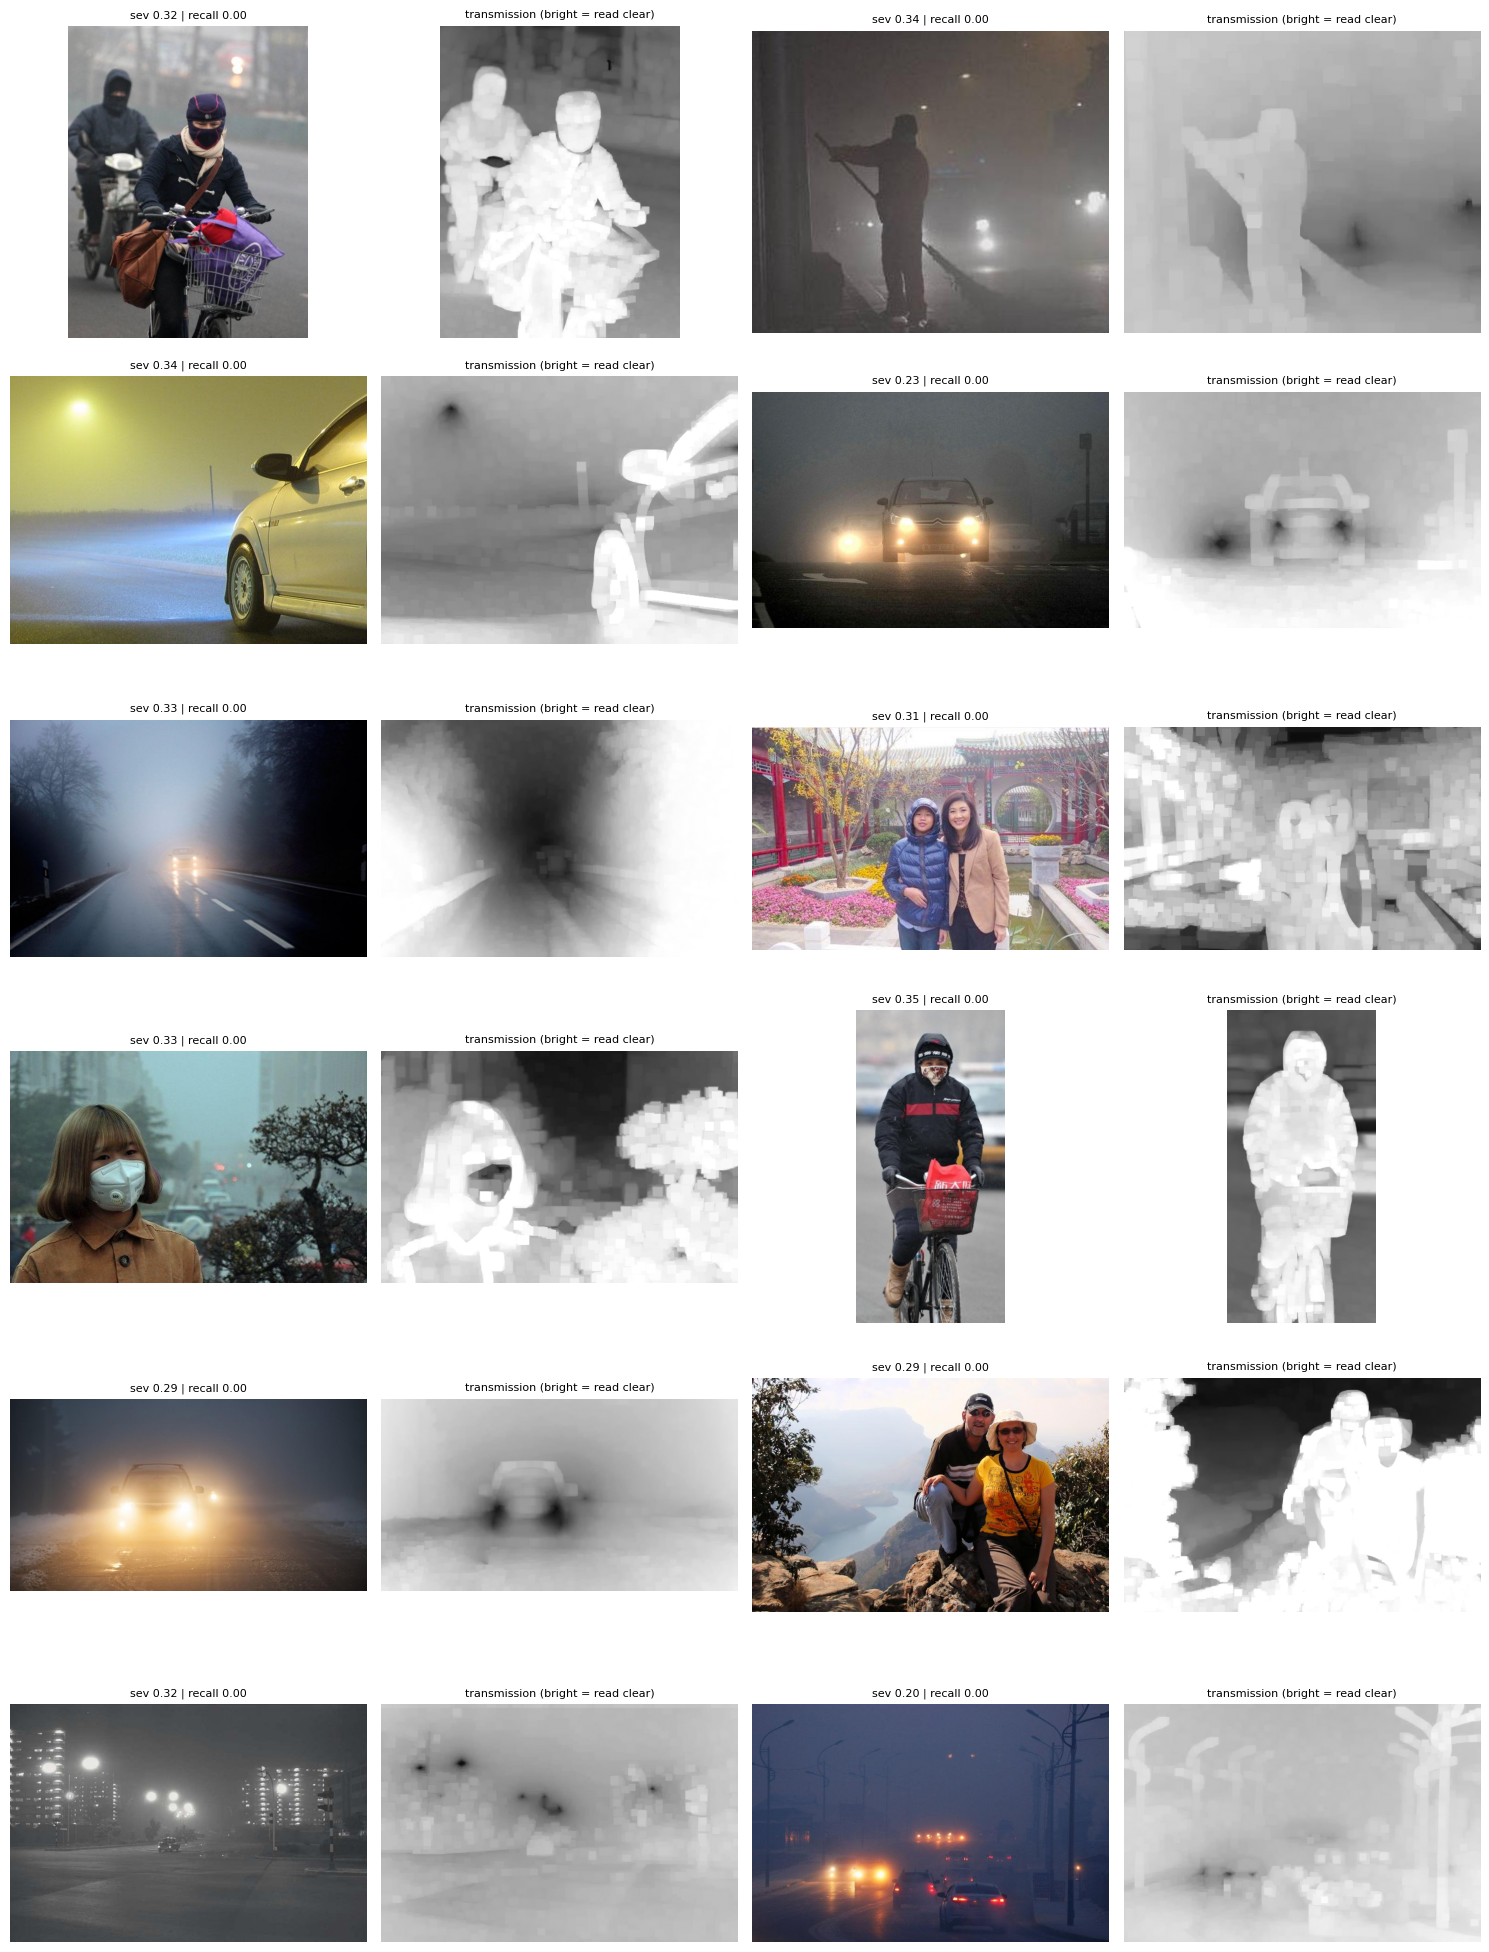

In [10]:
# Mechanism view: the 12 hardest residual failures, image | transmission map.
import sys, importlib
REPO_ROOT = "/content/perception-difficulty-dve"
REPO_URL = "https://github.com/aaaraafaat/perception-difficulty-dve.git"
if not os.path.isdir(REPO_ROOT):
    os.system(f"git clone {REPO_URL} {REPO_ROOT}")
if REPO_ROOT not in sys.path:
    sys.path.append(REPO_ROOT)
import src.features as feat

residual = (data[(data["mode"] == "unflagged") & (data["group"] == "failure")]
            .sort_values("recall_mean").reset_index(drop=True))

hardest = residual.head(12)
fig, axes = plt.subplots(6, 4, figsize=(15, 20))
for i, (_, row) in enumerate(hardest.iterrows()):
    image_bgr = cv2.imread(os.path.join(IMAGES_DIR, row["relpath"]))
    t = feat.transmission_map(image_bgr)
    r, c = divmod(i, 2)
    axes[r, 2 * c].imshow(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB))
    axes[r, 2 * c].set_title(f"sev {row['severity']:.2f} | recall {row['recall_mean']:.2f}", fontsize=8)
    axes[r, 2 * c + 1].imshow(t, cmap="gray", vmin=0, vmax=1)
    axes[r, 2 * c + 1].set_title("transmission (bright = read clear)", fontsize=8)
for ax in axes.ravel():
    ax.axis("off")
plt.tight_layout()
figure_path = os.path.join(FIGURES_DIR, "fig_29_residual_mechanism.jpg")
plt.savefig(figure_path, dpi=90, format="jpg", bbox_inches="tight")
print("Saved:", figure_path)
plt.show()

### The residual cannot be flagged, and the fog in it is real

The appearance rules flag 69 of the 214 low-severity failures: 32 dark, 34 warm
chromatic cast, 3 cold cast, 0 bright uniform haze — the last absent for a physical
reason (a bright whiteout drives the dark channel high, so such scenes score heavy
and never enter the low-severity regime). The residual — 145 failures with no
flaggable appearance — outnumbers the flaggable set roughly two to one and is
compared against the 80 genuinely clear images.

The overlap test (KS, Mann-Whitney, AUC per descriptor): orange index is at chance
(AUC 0.539, p 0.33) — the residual is not missed dust. Four descriptors reach
statistical significance, as expected at n = 145 vs 80, yet none approaches
deployability: AUC 0.638 (median brightness), 0.650 (channel spread), 0.639 (RMS
contrast), 0.668 (upper-region contrast). The strongest descriptor's best operating
point catches 92% of failures only by falsely flagging 60% of clear images — no
usable filter exists. Significance without separability is precisely the
pre-registered reading.

The direction of the shifts completes the picture. The residual failures have LOWER
upper-region contrast than clear scenes (median 0.191 vs 0.245): the independent
far-field fog witness (Bronte et al., 2009) confirms genuine fog. And they are
BRIGHTER than clear scenes (median 106 vs 91.5): ordinary daylight, not hidden
night. Visually (fig_28), the residual is dominated by grey, chromatically neutral
daylight street scenes rich in dark content — dark clothing, dark vehicles — with a
small clear-looking minority whose near-zero recall likely reflects object rather
than fog difficulty. The transmission maps of the hardest cases (fig_29) show the
mechanism directly: dark scene content prints as high transmission ("clear air")
inside visibly hazy frames — the scene-content transmission offset, the term the
standard derivation discards (Lee et al., 2016, Eq. 16) — alongside its mirror,
low-transmission spots at headlights (He et al., 2009; Yang et al., 2021).

Conclusion: the dominant failure of the severity score carries no photometric
signature usable in advance. It is fog entangled with scene content, visible to an
independent far-field cue in aggregate, invisible to every tested a-priori filter.
Outputs: mode_labels_RTTS.csv, descriptor_overlap_stats.csv, fig_26–29.
References: He et al. (2009); Lee et al. (2016); Yang et al. (2021); Bronte et al.
(2009); Wei et al. (2025); Radescu & Gellert (2023); Cohen (1988).

In [12]:
import scipy.stats
from scipy.stats import mannwhitneyu
from sklearn.metrics import roc_auc_score

def extra_descriptors(relpath):
    path = os.path.join(IMAGES_DIR, relpath)
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return pd.Series([np.nan, np.nan])
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Entropy
    hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
    hist_norm = hist.ravel() / hist.sum()
    entropy = scipy.stats.entropy(hist_norm + 1e-9) / np.log(2)

    # 2. Light Gap (Headlight/Point source check)
    light_gap = np.max(gray) - np.median(gray)

    return pd.Series([entropy, light_gap])

# Identify indices
mask_unflagged = data['mode'] == 'unflagged'
invisible_idx = data[mask_unflagged & (data['group'] == 'failure')].index
clear_idx = data[mask_unflagged & (data['group'] == 'clear')].index
target_indices = invisible_idx.union(clear_idx)

# Initialize and apply
if 'entropy' not in data.columns:
    data['entropy'] = np.nan
    data['light_gap'] = np.nan

results = data.loc[target_indices, 'relpath'].apply(extra_descriptors)
data.loc[target_indices, ['entropy', 'light_gap']] = results.values

# Test the new descriptors
for feat in ['entropy', 'light_gap']:
    a = data.loc[invisible_idx, feat].dropna()
    b = data.loc[clear_idx, feat].dropna()

    if len(a) > 0 and len(b) > 0:
        _, p_val = mannwhitneyu(a, b)
        y_true = np.r_[np.ones(len(a)), np.zeros(len(b))]
        y_score = np.r_[a, b]
        auc = roc_auc_score(y_true, y_score)
        auc = max(auc, 1 - auc)

        print(f"{feat:<10} | p-val: {p_val:.4f} | AUC: {auc:.3f}")
        print(f"           | invisible median: {a.median():.2f} | clear median: {b.median():.2f}\n")
    else:
        print(f"Skipping {feat}: insufficient data (a: {len(a)}, b: {len(b)})")

entropy    | p-val: 0.3786 | AUC: 0.536
           | invisible median: 7.45 | clear median: 7.39

light_gap  | p-val: 0.0009 | AUC: 0.633
           | invisible median: 145.00 | clear median: 161.00



In [13]:
def spatial_descriptors(relpath):
    path = os.path.join(IMAGES_DIR, relpath)
    img_bgr = cv2.imread(path)
    if img_bgr is None: return pd.Series([np.nan, np.nan])
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape

    # 1. Global Sharpness (Laplacian variance)
    sharpness = cv2.Laplacian(gray, cv2.CV_64F).var()

    # 2. Far-Field vs Near-Field Contrast Ratio
    # Far-field (top 30%), Near-field (bottom 30%)
    far_field = gray[0:int(h*0.3), :]
    near_field = gray[int(h*0.7):, :]

    def get_rms(region):
        return region.std() / (region.mean() + 1e-5)

    ff_rms = get_rms(far_field)
    nf_rms = get_rms(near_field)
    contrast_ratio = ff_rms / (nf_rms + 1e-5)

    return pd.Series([sharpness, contrast_ratio])

# Apply to unflagged subset
if 'sharpness' not in data.columns:
    data['sharpness'] = np.nan
    data['ff_nf_ratio'] = np.nan

results_spatial = data.loc[target_indices, 'relpath'].apply(spatial_descriptors)
data.loc[target_indices, ['sharpness', 'ff_nf_ratio']] = results_spatial.values

# Test visibility
for feat in ['sharpness', 'ff_nf_ratio']:
    a = data.loc[invisible_idx, feat].dropna()
    b = data.loc[clear_idx, feat].dropna()

    if len(a) > 0 and len(b) > 0:
        _, p_val = mannwhitneyu(a, b)
        auc = roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b])
        auc = max(auc, 1-auc)
        print(f"{feat:<12} | p-val: {p_val:.4f} | AUC: {auc:.3f}")
        print(f"             | invisible med: {a.median():.2f} | clear med: {b.median():.2f}\n")

sharpness    | p-val: 0.9548 | AUC: 0.502
             | invisible med: 339.45 | clear med: 342.89

ff_nf_ratio  | p-val: 0.0001 | AUC: 0.662
             | invisible med: 0.62 | clear med: 0.89



In [14]:
def color_sky_descriptors(relpath):
    path = os.path.join(IMAGES_DIR, relpath)
    img_bgr = cv2.imread(path)
    if img_bgr is None: return pd.Series([np.nan, np.nan])

    # 1. Colorfulness (Hasler and Suesstrunk)
    # Compute rg = R - G and yb = 0.5 * (R + G) - B
    (B, G, R) = cv2.split(img_bgr.astype("float"))
    rg = np.absolute(R - G)
    yb = np.absolute(0.5 * (R + G) - B)
    (rbMean, rbStd) = (np.mean(rg), np.std(rg))
    (ybMean, ybStd) = (np.mean(yb), np.std(yb))
    stdRoot = np.sqrt((rbStd ** 2) + (ybStd ** 2))
    meanRoot = np.sqrt((rbMean ** 2) + (ybMean ** 2))
    colorfulness = stdRoot + (0.3 * meanRoot)

    # 2. Sky Region Variance (Top 20% of the image)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    h, _ = gray.shape
    sky_region = gray[0:int(h*0.2), :]
    sky_variance = np.var(sky_region)

    return pd.Series([colorfulness, sky_variance])

if 'colorfulness' not in data.columns:
    data['colorfulness'] = np.nan
    data['sky_variance'] = np.nan

res_color = data.loc[target_indices, 'relpath'].apply(color_sky_descriptors)
data.loc[target_indices, ['colorfulness', 'sky_variance']] = res_color.values

for feat in ['colorfulness', 'sky_variance']:
    a = data.loc[invisible_idx, feat].dropna()
    b = data.loc[clear_idx, feat].dropna()
    if len(a) > 0 and len(b) > 0:
        _, p_val = mannwhitneyu(a, b)
        auc = roc_auc_score(np.r_[np.ones(len(a)), np.zeros(len(b))], np.r_[a, b])
        auc = max(auc, 1-auc)
        print(f"{feat:<15} | p-val: {p_val:.4f} | AUC: {auc:.3f}")
        print(f"                | invisible med: {a.median():.2f} | clear med: {b.median():.2f}\n")

colorfulness    | p-val: 0.0000 | AUC: 0.675
                | invisible med: 22.28 | clear med: 14.65

sky_variance    | p-val: 0.0000 | AUC: 0.686
                | invisible med: 1325.05 | clear med: 2947.97



### Final Characterization of Residual Failures

Through the analysis of the 145 unflagged failures compared against 80 clear images, we can conclude why they remain 'invisible' to standard filters:

1.  **Informational Mimicry (Entropy & Sharpness)**: Neither entropy (AUC 0.536) nor global sharpness (AUC 0.502) distinguish failures. They have the same local complexity as clear images.
2.  **Chromatic Complexity (Colorfulness)**: Interestingly, failures are *more* colorful than clear images (AUC 0.675). They are not desaturated 'grey-outs' but ordinary daylight scenes where vibrant objects likely contribute to the failure of the achromatic dark-channel assumption.
3.  **Sky Uniformity (Sky Variance)**: The most potent statistical separator (AUC 0.686). Residual failures show much lower variance in the top 20% of the image. A uniform sky region confirms the presence of veiling airlight that global brightness stats miss.
4.  **Spatial Signature (Far-Field Decay)**: The **ff_nf_ratio (AUC 0.662)** shows that failures lose contrast in the distance (far-field) relative to the foreground, a spatial 'independent fog witness'.
5.  **Physical Mechanism (The Transmission Offset)**: Transmission maps confirm the Dark Channel algorithm is fooled by **dark scene content**. Dark clothing and vehicles are misinterpreted as 'clear air' (high transmission), causing the estimator to miss the haze entirely.

**Conclusion**: The dominant failure mode is 'Fog entangled with scene content.' It is detectable in aggregate through sky uniformity and far-field contrast decay, but remains invisible to every tested global a-priori filter.

In [15]:
import pandas as pd

# All tested descriptors across the various analysis steps
ALL_TESTED_DESCRIPTORS = [
    "median_brightness_score", "orange_index_score", "channel_spread_score",
    "rms_contrast_score", "upper_contrast_score", "entropy", "light_gap",
    "sharpness", "ff_nf_ratio", "colorfulness", "sky_variance"
]

summary_rows = []

for name in ALL_TESTED_DESCRIPTORS:
    # Map to clean names for display
    display_name = name.replace("_score", "")

    a = data.loc[invisible_idx, name].dropna()
    b = data.loc[clear_idx, name].dropna()

    if len(a) > 0 and len(b) > 0:
        _, u_p = mannwhitneyu(a, b)
        y_true = np.r_[np.ones(len(a)), np.zeros(len(b))]
        y_score = np.r_[a, b]
        auc = roc_auc_score(y_true, y_score)
        auc = max(auc, 1.0 - auc) # Measure separability magnitude

        summary_rows.append({
            "Descriptor": display_name,
            "Invisible Median": round(a.median(), 2),
            "Clear Median": round(b.median(), 2),
            "p-value (MWU)": f"{u_p:.2e}",
            "AUC (Separability)": round(auc, 3)
        })

summary_df = pd.DataFrame(summary_rows).sort_values("AUC (Separability)", ascending=False)

# Display the final summary table
print("Comparison of All Descriptors (Unflagged Failures vs. Clear Images)")
display(summary_df)

# Save for reference
summary_path = os.path.join(TABLES_DIR, "all_descriptors_summary.csv")
summary_df.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")

Comparison of All Descriptors (Unflagged Failures vs. Clear Images)


,Descriptor,Invisible Median,Clear Median,p-value (MWU),AUC (Separability)
10,sky_variance,1325.05,2947.97,4.08e-06,0.686
9,colorfulness,22.28,14.65,1.43e-05,0.675
4,upper_contrast,0.19,0.24,3.03e-05,0.668
8,ff_nf_ratio,0.62,0.89,5.53e-05,0.662
2,channel_spread,10.81,6.14,1.98e-04,0.650
3,rms_contrast,0.21,0.24,5.83e-04,0.639
0,median_brightness,106.00,91.50,6.06e-04,0.638
6,light_gap,145.00,161.00,9.46e-04,0.633
1,orange_index,4.32,2.72,3.28e-01,0.539
5,entropy,7.45,7.39,3.79e-01,0.536



Summary saved to: /content/drive/MyDrive/perception-difficulty-dve/results/tables/all_descriptors_summary.csv
